# kBET Analysis

**Analysis 1: DMSO only, patient as batch**  
Subset to DMSO-treated wells across all patients, then ask if patient identity drives local structure in morphological feature space?


In [1]:
list_of_packages <- c("arrow", "dplyr", "ggplot2", "kBET")
for (package in list_of_packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(
                package,
                character.only = TRUE,
                quietly = TRUE,
                warn.conflicts = FALSE
            )
        )
    )
}

In [2]:
find_git_root <- function() {
    cwd <- getwd()
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }
    current_path <- cwd
    while (dirname(current_path) != current_path) {
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }
    stop("No Git root directory found.")
}

root_dir <- find_git_root()
cat("Git root directory:", root_dir, "\n")

figures_path <- file.path(root_dir, "1.EDA/figures/kbet")
dir.create(figures_path, recursive = TRUE, showWarnings = FALSE)

Git root directory: /Users/kaylorhuang/Documents/GitHub_Repos/Kaylor---NF1_organoid_profile_analysis 


In [3]:
profiles <- list(
    list(
        label   = "2D_organoid",
        path    = file.path(root_dir, "data/2D_profiles/all_patient_profiles/max_projection/organoid_fs_profiles.parquet"),
        is_3d   = FALSE
    ),
    list(
        label   = "2D_singlecell",
        path    = file.path(root_dir, "data/2D_profiles/all_patient_profiles/max_projection/sc_fs_profiles.parquet"),
        is_3d   = FALSE
    ),
    list(
        label   = "3D_organoid",
        path    = file.path(root_dir, "data/3D_profiles/all_patient_profiles/organoid_fs_profiles.parquet"),
        is_3d   = TRUE
    ),
    list(
        label   = "3D_singlecell",
        path    = file.path(root_dir, "data/3D_profiles/all_patient_profiles/sc_fs_profiles.parquet"),
        is_3d   = TRUE
    )
)

In [4]:
prep_features <- function(df) {
    meta_cols <- grep("^Metadata_", colnames(df), value = TRUE)
    metadata_df   <- df %>% select(all_of(meta_cols))
    morphology_df <- df %>% select(-all_of(meta_cols))

    # keep only numeric columns
    numeric_cols <- sapply(morphology_df, is.numeric)
    morphology_df <- morphology_df[, numeric_cols, drop = FALSE]

    # drop constant columns
    constant_cols <- sapply(morphology_df, function(x) length(unique(na.omit(x))) <= 1)
    morphology_df <- morphology_df[, !constant_cols, drop = FALSE]

    # drop all-NA columns, then mean-impute remaining NAs
    all_na_cols <- sapply(morphology_df, function(x) all(is.na(x)))
    morphology_df <- morphology_df[, !all_na_cols, drop = FALSE]
    morphology_df <- as.data.frame(lapply(morphology_df, function(x) {
        if (any(is.na(x))) { x[is.na(x)] <- mean(x, na.rm = TRUE) }
        x
    }))

    list(morphology = morphology_df, metadata = as.data.frame(metadata_df))
}

## DMSO only, patient as batch

Isolating the DMSO condition removes treatment-driven variation, so any remaining clustering reflects patient identity alone.

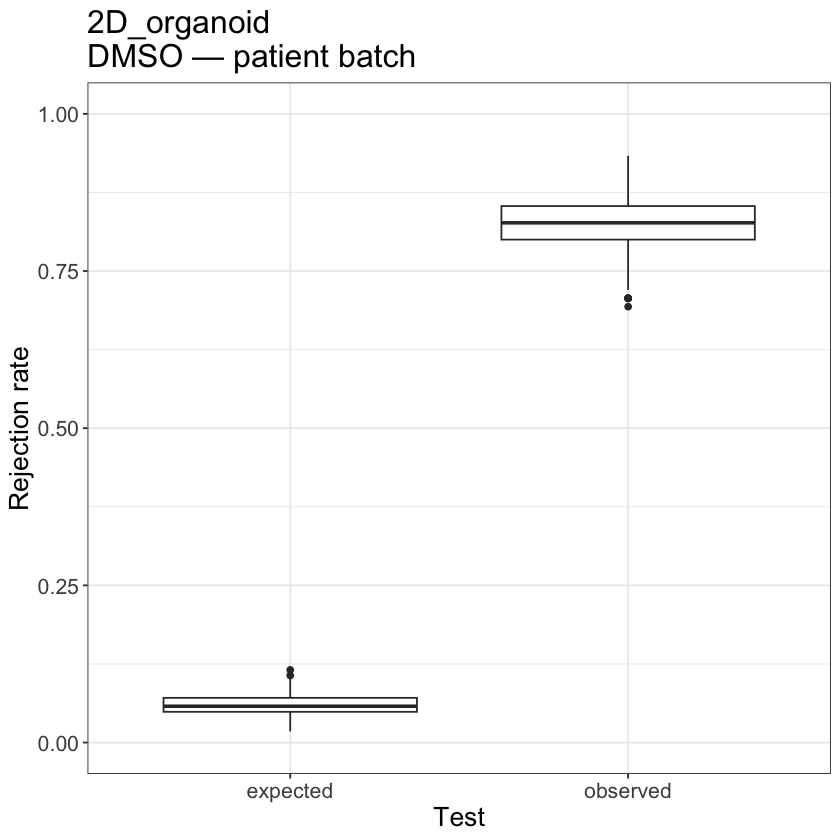

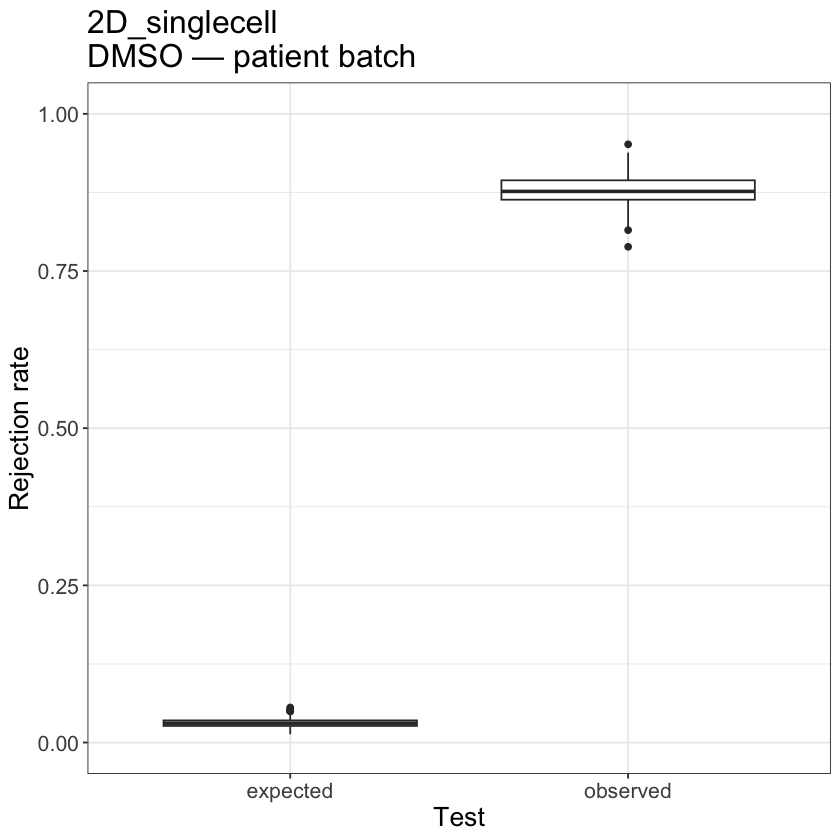

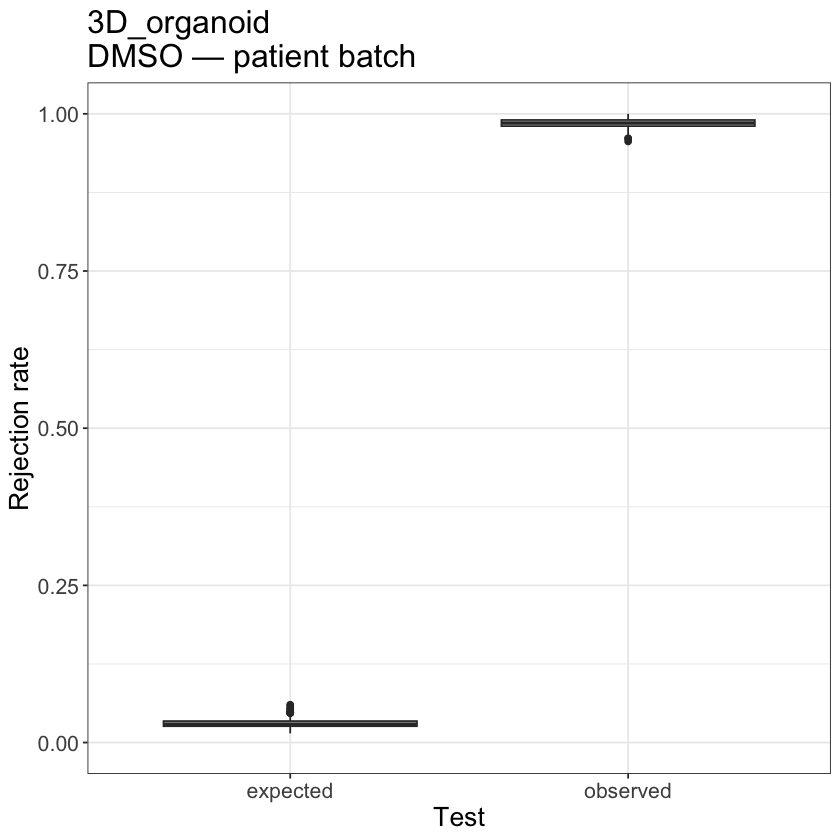

profile_type,observed_rejection_rate,expected_rejection_rate,p_value
<chr>,<dbl>,<dbl>,<dbl>
2D_organoid,0.8218000,0.06095556,0
2D_singlecell,0.8773040,0.03125257,0
3D_organoid,0.9870976,0.03031870,0
3D_singlecell,0.9990652,0.03851006,0


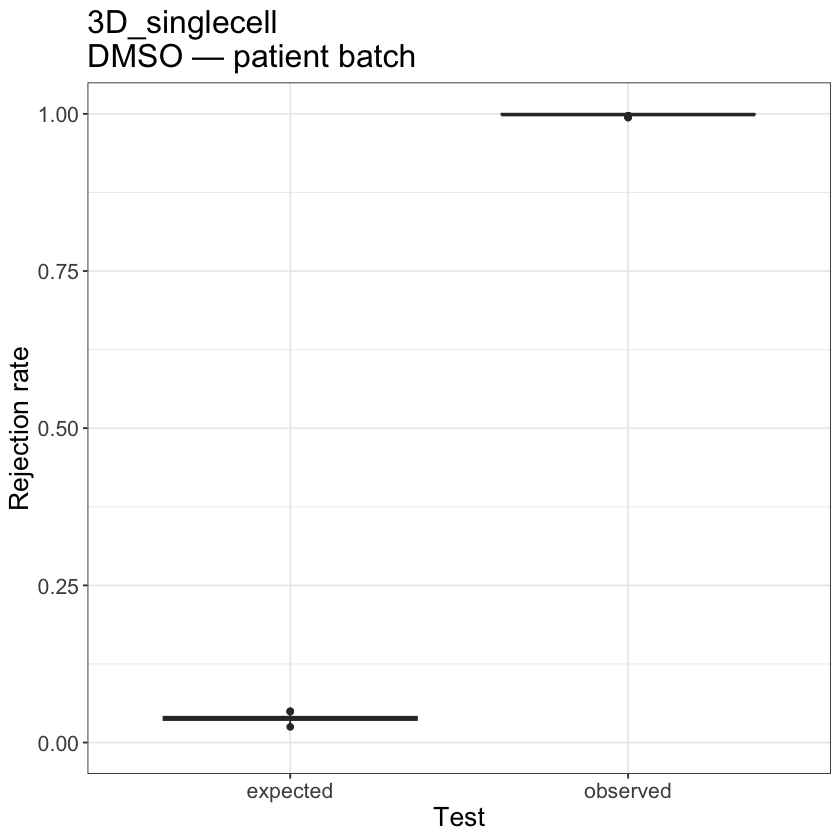

In [5]:
dmso_results <- list()

for (prof in profiles) {
    df <- arrow::read_parquet(prof$path)

    # harmonize NF0037_T1 treatment names in 3D data
    if (prof$is_3d) {
        df <- df %>%
            mutate(Metadata_treatment = ifelse(
                Metadata_patient_tumor == "NF0037_T1",
                gsub(" \\d+$", "", Metadata_treatment),
                Metadata_treatment
            ))
    }

    # subset to DMSO across all patients
    df_dmso <- df %>% filter(Metadata_treatment == "DMSO")

    prepped      <- prep_features(df_dmso)
    batch_labels <- prepped$metadata[["Metadata_patient_tumor"]]

    set.seed(0)
    result <- tryCatch(
        kBET(prepped$morphology, batch_labels, n_repeat = 1000, plot = FALSE),
        error = function(e) {
            NULL
        }
    )

    if (is.null(result) || !is.list(result) || is.null(result$summary)) next

    # individual boxplot
    plot.data <- data.frame(
        class = rep(c("observed", "expected"), each = length(result$stats$kBET.observed)),
        data  = c(result$stats$kBET.observed, result$stats$kBET.expected)
    )
    p <- ggplot(plot.data, aes(class, data)) +
        geom_boxplot() +
        labs(
            x     = "Test",
            y     = "Rejection rate",
            title = paste0(prof$label, "\nDMSO — patient batch")
        ) +
        theme_bw() +
        theme(text = element_text(size = 16)) +
        scale_y_continuous(limits = c(0, 1))
    print(p)

    ggsave(
        file.path(figures_path, paste0("kbet_dmso_", prof$label, "_patient.png")),
        p, width = 5, height = 7, units = "in", dpi = 300
    )

    dmso_results[[length(dmso_results) + 1]] <- data.frame(
        profile_type            = prof$label,
        observed_rejection_rate = result$summary["mean", "kBET.observed"],
        expected_rejection_rate = result$summary["mean", "kBET.expected"],
        p_value                 = result$summary["mean", "kBET.signif"],
        stringsAsFactors        = FALSE
    )
}

dmso_summary <- do.call(rbind, dmso_results)
head(dmso_summary)

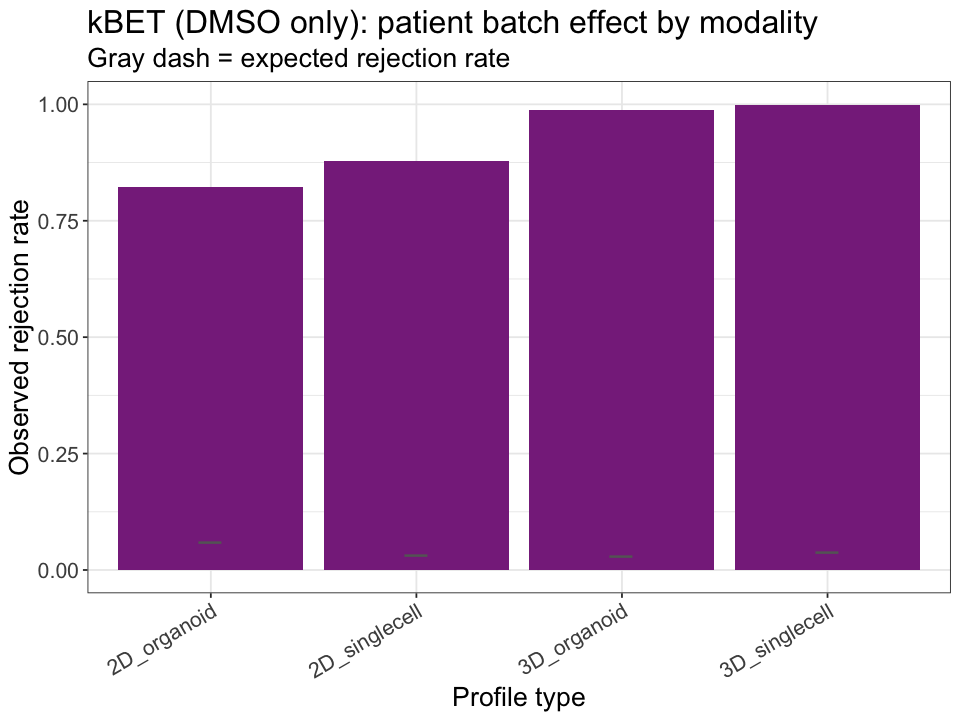

In [6]:
dmso_summary$profile_type <- factor(
    dmso_summary$profile_type,
    levels = c("2D_organoid", "2D_singlecell", "3D_organoid", "3D_singlecell")
)

options(repr.plot.width = 8, repr.plot.height = 6)
dmso_plot <- ggplot(dmso_summary, aes(x = profile_type, y = observed_rejection_rate)) +
    geom_col(fill = "#882E8B") +
    geom_point(aes(y = expected_rejection_rate), shape = 95, size = 8, color = "gray40") + # shape 95 = horizontal dash
    labs(
        x        = "Profile type",
        y        = "Observed rejection rate",
        title    = "kBET (DMSO only): patient batch effect by modality",
        subtitle = "Gray dash = expected rejection rate"
    ) +
    theme_bw() +
    theme(
        text        = element_text(size = 16),
        axis.text.x = element_text(angle = 30, hjust = 1)
    ) +
    scale_y_continuous(limits = c(0, 1))

dmso_plot

ggsave(
    file.path(figures_path, "kbet_dmso_patient_summary.png"),
    dmso_plot, width = 7, height = 6, units = "in", dpi = 300
)